# 🎹 MusicTransformer — Build a Composer from Scratch

> *Feed it the opening of Ode to Joy. Watch it compose the next 32 notes. Hear it play.*

---

## 🧠 What you're building

A proper **decoder-only Transformer** — the same architecture as GPT — trained on
15 famous melodies. By the end it will auto-regressively generate new music and
you'll hear it play inside the notebook.

## 📐 Architecture

```
Token IDs  →  Embedding  →  PositionalEncoding
           →  TransformerBlock × 2
                 ├─ MultiHeadAttention (4 heads, causal mask)
                 └─ FeedForward (GELU)
                 ↑ both wrapped in: residual + LayerNorm
           →  Linear output head
           →  Logits (one score per note)
```

## 📋 Your TODOs at a glance

| # | What | New concept |
|---|------|-------------|
| 1 | Build vocab dict | same as class |
| 2 | `tokenize()` function | same as class |
| 3 | Positional Encoding (sin/cos) | 🆕 position fingerprints |
| 4 | Multi-Head Attention | 🆕 parallel attention heads |
| 5 | Residual + LayerNorm in TransformerBlock | 🆕 residual connections |
| 6 | Assemble MusicTransformer | 🆕 nn.ModuleList |
| 7 | Loss fn + optimiser | same as class |
| 8 | Training loop (backprop) | same as class |
| 9 | Temperature sampling | 🆕 sampling vs argmax |

## 📌 Rules
- Run cells **top to bottom**.
- Replace every `___` with code. Each blank has a hint comment above it.
- Stuck? Open the `💡 Hint` dropdown.
- **Nothing to install** — runs on Google Colab CPU in ~3 minutes.


## 🔧 Step 0 — Imports

*Just run this — no blanks.*

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

torch.manual_seed(42)
np.random.seed(42)

print("✅ Imports ready!")
print(f"   PyTorch {torch.__version__}")


✅ Imports ready!
   PyTorch 2.11.0+cu128


## 🎼 Step 1 — Dataset: 15 Famous Melodies

*Just run this — no blanks.*

We train on overlapping 8-note windows extracted from 15 classic melodies.
Every melody is encoded as a sequence of note names like `"C4 D4 E4 G4 ..."`.

The model will learn patterns like:
> *"After E4 E4 F4 G4, what comes next?"* → G4 (Ode to Joy!)

### Note vocabulary

| Octave 3 | Octave 4 | Octave 5 |
|----------|----------|----------|
| G3 A3 B3 | C4 D4 E4 F4 G4 A4 B4 | C5 D5 E5 |

Plus one special token: `REST` (silence).


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

torch.manual_seed(42)
np.random.seed(42)

print("✅ Imports ready!")
print(f"   PyTorch {torch.__version__}")

# ── Frequencies (Hz) for every note we use ──────────────────────────────────
NOTE_FREQ = {
    "G3": 196.00, "A3": 220.00, "B3": 246.94,
    "C4": 261.63, "C#4": 277.18, "D4": 293.66, "E4": 329.63, "F4": 349.23, "F#4": 369.99,
    "G4": 392.00, "A4": 440.00, "B4": 493.88,
    "C5": 523.25, "C#5": 554.37, "D5": 587.33, "D#5": 622.25, "E5": 659.25, "F5": 698.46, "F#5": 739.99, "G5": 784.00,
    "F3": 174.61,
    "A5": 880.00,
    "REST": 0.0,
}

# ── 15 melodies encoded as space-separated note strings ─────────────────────
MELODIES = {

"Twinkle Twinkle Little Star":
"C4 C4 G4 G4 A4 A4 G4 F4 F4 E4 E4 D4 D4 C4",

"Happy Birthday":
"G4 G4 A4 G4 C5 B4 G4 G4 A4 G4 D5 C5",

"Jingle Bells":
"E4 E4 E4 E4 E4 E4 E4 G4 C4 D4 E4",

"Ode to Joy":
"E4 E4 F4 G4 G4 F4 E4 D4 C4 C4 D4 E4 E4 D4 D4",

"Mary Had a Little Lamb":
"E4 D4 C4 D4 E4 E4 E4 D4 D4 D4 E4 G4 G4",

"London Bridge":
"G4 A4 G4 F4 E4 F4 G4 D4 E4 F4 E4 F4 G4",

"Row Row Row Your Boat":
"C4 C4 C4 D4 E4 E4 D4 E4 F4 G4",

"Old MacDonald":
"C4 C4 C4 G3 A3 A3 G3 E4 E4 D4 D4 C4",

"Baa Baa Black Sheep":
"C4 C4 G4 G4 A4 A4 G4 F4 F4 E4 E4 D4",

"Rain Rain Go Away":
"C4 C4 D4 C4 F4 E4 C4",

"ABC Song":
"C4 C4 G4 G4 A4 A4 G4 F4 F4 E4 E4 D4",

"Five Little Ducks":
"C4 C4 C4 D4 E4 E4 D4 C4",

"Humpty Dumpty":
"C4 C4 D4 E4 G4 G4 E4",

"Jack and Jill":
"C4 D4 E4 F4 G4 G4",

"Rock A Bye Baby":
"C5 G4 A4 G4 F4 E4 D4",

"We Wish You a Merry Christmas":
"G4 C5 C5 D5 C5 B4 A4 A4",

"Silent Night":
"G4 A4 G4 E4 G4 A4 G4 E4",

"Amazing Grace":
"G4 C5 E5 C5 E5 D5 C5 A4",

"Happy Farmer":
"C4 D4 E4 F4 G4 G4 F4 E4",

"Frere Jacques":
"C4 D4 E4 C4 C4 D4 E4 C4",

"Scarborough Fair Theme":
"A4 C5 E5 D5",

"House of Rising Sun":
"A4 C5 E5 A5",

"Shenandoah":
"G4 A4 C5",

"Deck The Halls":
"G4 F4 E4 D4",

"O Christmas Tree":
"C4 F4 F4",

"Carol of Bells":
"E5 D5 E5 C5",

"Little Star Variation":
"C5 G4 A4 F4",

"Baby Shark":
"C4 C4 C4 C4",

"Wheels on Bus":
"C4 F4 F4",

"Finger Family":
"C4 C4 G4",

"If You're Happy":
"C4 C4 F4 F4",

"Head Shoulders Knees":
"C4 C4 C4",

"Alphabet Melody":
"C4 D4 E4 F4 G4",

"Three Blind Mice":
"E4 D4 C4",

"Itsy Bitsy Spider":
"C4 F4 F4",

"Ants Go Marching":
"G4 G4 E4",

"London Bells":
"G4 G4 A4",

"Pop Goes Weasel":
"C5 A4",

"Chopsticks":
"C4 E4",

"Heart and Soul":
"C4 E4 G4",

"Prelude C Major":
"C4 D4 E4 G4",

"Rondo Alla Turca":
"A4 A4 B4 C5",

"William Tell":
"E4 E4 E4",

"Eine Kleine":
"G4 G4 D5",

"Vivaldi Spring":
"E5 E5 F5 G5",

"Scarlet Theme":
"D4 E4 F4 G4",
"Ocean Theme":
"C5 B4 A4 G4",

"Dream Melody":
"C5 E5 G5",

"Simple Waltz":
"C4 E4 G4 C5"

}


# ── Validate all notes exist in NOTE_FREQ ────────────────────────────────────
for name, melody in MELODIES.items():
    for note in melody.split():
        assert note in NOTE_FREQ, f"Note '{note}' in '{name}' not in NOTE_FREQ!"

all_tokens   = sorted({n for seq in MELODIES.values() for n in seq.split()})
total_notes  = sum(len(seq.split()) for seq in MELODIES.values())

print(f"📊 Dataset summary")
print(f"   Melodies      : {len(MELODIES)}")
print(f"   Total notes   : {total_notes}")
print(f"   Unique tokens : {len(all_tokens)}  →  {all_tokens}")

## 🔢 Step 2 — Vocabulary & Tokenisation

Transformers work with integers, not strings.
We need two dictionaries:
- `vocab`     — note name → integer ID  *(for encoding)*
- `inv_vocab` — integer ID → note name  *(for decoding predictions)*


In [ ]:
# ── TODO 1: Build the vocab dictionary ─────────────────────────────────────
#
# `all_tokens` is a sorted list of every unique note name in the dataset.
# Create a dict that maps  note_name → integer_id.
#
# Pattern from class:
#   vocab = { word : idx  for idx, word in enumerate(word_list) }
#
vocab     = {note : idx for idx, note in enumerate(all_tokens)}
inv_vocab = {idx: note for note, idx in vocab.items()}

VOCAB_SIZE = len(vocab)
print(f"Vocabulary ({VOCAB_SIZE} tokens):")
for note, idx in vocab.items():
    print(f"  {idx:2d}: {note}")


In [ ]:
import torch

# ── TODO 2: Write the tokenize() function ───────────────────────────────────
#
# Input:  list of note name strings, e.g. ["C4", "E4", "G4"]
# Output: 1-D LongTensor of IDs,     e.g. tensor([4, 8, 11])
#
# Hint:  token_ids = [vocab[note] for note in notes]
#        return torch.tensor(token_ids, dtype=torch.long)
#
def tokenize(notes):
    token_ids = [vocab[note] for note in notes]
    return torch.tensor(token_ids, dtype=torch.long)

### Build sliding-window training pairs

*Just run this — no blanks.*

We slide an 8-note window across every melody:
```
[C4 C4 G4 G4 A4 A4 G4 F4]  →  predict  F4   ← window 0
[C4 G4 G4 A4 A4 G4 F4 F4]  →  predict  E4   ← window 1
...
```


In [ ]:
CONTEXT_LEN = 8   # model sees 8 notes, predicts the 9th

X_list, y_list = [], []
for name, melody_str in MELODIES.items():
    notes = melody_str.split()
    ids   = tokenize(notes).tolist()
    for i in range(len(ids) - CONTEXT_LEN):
        X_list.append(ids[i : i + CONTEXT_LEN])
        y_list.append(ids[i + CONTEXT_LEN])

X_all = torch.tensor(X_list, dtype=torch.long)   # (N, CONTEXT_LEN)
y_all = torch.tensor(y_list, dtype=torch.long)   # (N,)

print(f"✅ Training windows : {len(X_all)}")
print(f"   X_all shape      : {X_all.shape}   (num_windows × context_len)")
print(f"   y_all shape      : {y_all.shape}   (num_windows,)")
print()
print("Example window #10:")
print("  Input :", [inv_vocab[i] for i in X_all[10].tolist()])
print("  Target:", inv_vocab[y_all[10].item()])


## 🏗️ Step 3 — Build the Model

We'll build the model **bottom-up**, one class at a time:

```
PositionalEncoding       ← TODO 3
MultiHeadAttention       ← TODO 4
TransformerBlock         ← TODO 5
MusicTransformer         ← TODO 6
```

Each class has a **quick shape test** cell after it so you know immediately if something is wrong.

### Model hyperparameters


In [ ]:
D_MODEL  = 128
N_HEADS  = 4
D_FF     = 256
DROPOUT  = 0.1
MAX_LEN  = 200

print(f"d_model  = {D_MODEL}  ({N_HEADS} heads × {D_MODEL//N_HEADS} dims/head)")
print(f"d_ff     = {D_FF}")
print(f"n_layers = {N_LAYERS}")
print(f"dropout  = {DROPOUT}")


### 3a — Positional Encoding

**Problem:** A Transformer processes all tokens simultaneously (unlike an RNN).
Without position information, `C4 D4 E4` and `E4 D4 C4` look identical.

**Fix:** Add a fixed *fingerprint* to each position using sin and cos waves
at different frequencies. No learning required — it's pure maths.

**Formula** (Vaswani et al., 2017 — *"Attention Is All You Need"*):

```
PE[pos, 2i]   =  sin( pos / 10000^(2i / d_model) )
PE[pos, 2i+1] =  cos( pos / 10000^(2i / d_model) )
```

- `pos` = position index (0, 1, 2, ...)
- `i`   = dimension index (0, 1, 2, ... up to d_model/2)
- Even columns → **sin**,  Odd columns → **cos**


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Allocate the PE table: shape (max_len, d_model)
        pe = torch.zeros(max_len, d_model)

        # position: [[0], [1], [2], ..., [max_len-1]]  shape (max_len, 1)
        position = torch.arange(0, max_len).unsqueeze(1).float()

        # div_term[i]  =  exp( -2i/d_model * log(10000) )
        #              =  1 / 10000^(2i/d_model)
        # shape: (d_model/2,)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        # TODO 3a: Fill EVEN columns (0, 2, 4, ...) with SINE
        # Hint:  pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 0::2] = torch.sin(position * div_term)

        # TODO 3b: Fill ODD columns (1, 3, 5, ...) with COSINE
        # Hint:  pe[:, 1::2] = torch.cos(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Register as a non-learnable buffer (saved with the model but not updated)
        # Add batch dimension → (1, max_len, d_model)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        # Add PE for the first seq_len positions; broadcasting handles the batch dim
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

# ── Shape test (should print torch.Size([2, 8, 64])) ─────────────────────────
_pe  = PositionalEncoding(D_MODEL, MAX_LEN, DROPOUT)
_x   = torch.zeros(2, 8, D_MODEL)
_out = _pe(_x)
print("PE output shape:", _out.shape)
assert _out.shape == torch.Size([2, 8, D_MODEL]), "❌ Shape mismatch — check your sin/cos lines"
print("✅ PositionalEncoding — shape correct!")


### 3b — Multi-Head Attention

**Single-head** attention (from class) computes one set of attention weights over the whole
`d_model` space. With **multi-head** attention, we run `n_heads` independent attention
operations in parallel on smaller `d_head = d_model // n_heads` slices.

This lets different heads specialise:
> Head 1: *"which note was 2 steps ago?"*
> Head 2: *"is this a rising or falling phrase?"*
> Head 3: *"what key are we in?"*

```
Input x  (B, T, D)
    ↓  project W_q / W_k / W_v
Q, K, V  (B, T, D)
    ↓  split into H heads
Q, K, V  (B, H, T, D//H)
    ↓  scaled dot-product attention  (with causal mask)
context  (B, H, T, D//H)
    ↓  merge heads
context  (B, T, D)
    ↓  final projection W_o
output   (B, T, D)
```


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads   # dims per head  e.g. 64//4 = 16

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, D = x.shape   # batch, seq_len, d_model

        # 1. Project to Q, K, V
        Q = self.W_q(x)   # (B, T, D)
        K = self.W_k(x)
        V = self.W_v(x)

        # ── TODO 4a: Split into heads ─────────────────────────────────────────
        # Target shape: (B, n_heads, T, d_head)
        #
        # Step 1 — reshape last dim into (n_heads, d_head):
        #   .view(B, T, self.n_heads, self.d_head)
        # Step 2 — swap dims 1 and 2 so heads come before T:
        #   .transpose(1, 2)
        #
        # Q is done for you as an example — apply the same to K and V.
        Q = Q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = K.view(B,T,self.n_heads,self.d_head).transpose(1,2)   # same two steps as Q
        V = V.view(B,T,self.n_heads,self.d_head).transpose(1,2)  # same two steps as Q

        # ── TODO 4b: Scaled dot-product attention scores ──────────────────────
        # scores = Q @ K^T  ÷  sqrt(d_head)
        #
        # Q shape : (B, H, T, d_head)
        # K^T shape: (B, H, d_head, T)   ← K.transpose(-2, -1)
        # scores shape: (B, H, T, T)
        #
        # Hint: torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)
        scores =  torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)

        # ── Causal mask (provided — do not change) ────────────────────────────
        # Prevents position i from attending to positions j > i.
        # This makes the model properly auto-regressive (GPT-style).
        mask   = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float('-inf'))

        # ── TODO 4c: Softmax → attention weights → weighted sum of V ─────────
        # weights = F.softmax(scores, dim=-1)    shape: (B, H, T, T)
        # context = weights @ V                  shape: (B, H, T, d_head)
        #
        # Hint: use F.softmax(..., dim=-1) then torch.matmul(...)
        weights = F.softmax(scores,dim=-1)
        weights = self.dropout(weights)
        context = weights @ V

        # ── TODO 4d: Merge heads back into (B, T, D) ─────────────────────────
        # Step 1: .transpose(1, 2)               → (B, T, H, d_head)
        # Step 2: .contiguous().view(B, T, D)    → (B, T, D)
        #
        # .contiguous() is needed because transpose doesn't rearrange memory;
        # .view() requires contiguous memory layout.
        context = context.transpose(1,2).contiguous().view(B,T,self.d_model)
        # Final output projection
        return self.W_o(context)

# ── Shape test ────────────────────────────────────────────────────────────────
_mha = MultiHeadAttention(D_MODEL, N_HEADS, DROPOUT)
_x   = torch.randn(2, 8, D_MODEL)
_out = _mha(_x)
print("MHA output shape:", _out.shape)
assert _out.shape == torch.Size([2, 8, D_MODEL]), "❌ Check your view/transpose/matmul steps"
print("✅ MultiHeadAttention — shape correct!")


### 3c — Transformer Block

Each block wraps attention and the FFN with two key additions:

**Residual connection:** `x = x + sublayer(x)`
- The shortcut path lets gradients skip the sublayer during backprop.
- This is why transformers can be stacked 96+ layers deep without vanishing gradients.

**Layer Normalisation:** normalises each token's vector to mean≈0, std≈1.
- Applied *after* the residual: `x = LayerNorm(x + sublayer(x))`
- This stabilises training by keeping activations in a predictable range.

**GELU activation** (in the FFN): smoother version of ReLU used in all modern
transformers (GPT, BERT, etc.). Defined as `x · Φ(x)` where `Φ` is the
Gaussian CDF — approximated as `0.5x(1 + tanh(√(2/π)(x + 0.044715x³)))`.


In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn    = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn     = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),                    # smoother than ReLU; standard in modern transformers
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # ── TODO 5a: Attention sub-layer with residual + LayerNorm ───────────
        #
        # Pattern:  x = self.norm1( x + self.dropout(sublayer(x)) )
        #
        # Hint:
        #   attn_out = self.attn(x)
        #   x = self.norm1(x + self.dropout(attn_out))
        attn_out = self.attn(x)
        x        = self.norm1(x+self.dropout(attn_out))

        # ── TODO 5b: FFN sub-layer with residual + LayerNorm ─────────────────
        #
        # Same pattern as above — use self.ffn, self.norm2
        #
        # Hint:
        #   ffn_out = self.ffn(x)
        #   x = self.norm2(x + self.dropout(ffn_out))
        ffn_out = self.ffn(x)
        x       = self.norm2(x + self.dropout(ffn_out))

        return x

# ── Shape test ────────────────────────────────────────────────────────────────
_blk = TransformerBlock(D_MODEL, N_HEADS, D_FF, DROPOUT)
_x   = torch.randn(2, 8, D_MODEL)
_out = _blk(_x)
print("Block output shape:", _out.shape)
assert _out.shape == torch.Size([2, 8, D_MODEL]), "❌ Check your residual/norm lines"
print("✅ TransformerBlock — shape correct!")


### 3d — Assemble MusicTransformer

Now we wire all the pieces together into one `nn.Module`.

`nn.ModuleList` is a PyTorch list that properly registers all sub-module
parameters. If you used a plain Python list, the optimiser would never
see those parameters — a subtle but fatal bug.


In [ ]:
class MusicTransformer(nn.Module):
    """
    Decoder-only Transformer for melody generation.
    Architecture: Embedding + PositionalEncoding + N×TransformerBlock + Linear
    """
    def __init__(self, vocab_size, d_model, n_heads, d_ff,
                 n_layers, max_len=200, dropout=0.1):
        super().__init__()
        self.d_model = d_model

        self.embedding   = nn.Embedding(num_embeddings=vocab_size,embedding_dim=d_model)

        self.pos_enc     = PositionalEncoding(d_model,max_len,dropout)

        self.blocks      = nn.ModuleList([TransformerBlock(d_model, n_heads, d_ff, dropout)
                             for _ in range(n_layers)])


        self.output_proj =nn.Linear(d_model,vocab_size)

    def forward(self, x):

        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_enc(x)
        for block in self.blocks:
            x = block(x)
        return self.output_proj(x)


model = MusicTransformer(
    vocab_size = VOCAB_SIZE,
    d_model    = D_MODEL,
    n_heads    = N_HEADS,
    d_ff       = D_FF,
    n_layers   = N_LAYERS,
    max_len    = MAX_LEN,
    dropout    = DROPOUT,
)

# Count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ MusicTransformer created!")
print(f"   Parameters : {n_params:,}")
print(f"   GPT-3 has  : 175,000,000,000  (that's {175_000_000_000 // n_params:,}× bigger)")

# ── End-to-end shape test ─────────────────────────────────────────────────────
_xb  = torch.randint(0, VOCAB_SIZE, (4, CONTEXT_LEN))   # batch of 4 random sequences
_out = model(_xb)
print(f"\nForward pass test:")
print(f"  Input  shape: {_xb.shape}   (batch=4, seq_len={CONTEXT_LEN})")
print(f"  Output shape: {_out.shape}  (batch=4, seq_len={CONTEXT_LEN}, vocab={VOCAB_SIZE})")
assert _out.shape == (4, CONTEXT_LEN, VOCAB_SIZE), "❌ Check your layer definitions"
print("✅ Full model forward pass — shape correct!")


## 🏋️ Step 4 — Training

### Two things we need before the loop:
- **Loss function** — measures how wrong each prediction was.
- **Optimiser** — uses the gradients to nudge the weights a little bit.

Then the loop itself follows the same **3-line backprop pattern** as class.


In [ ]:
BATCH_SIZE = 64
NUM_EPOCHS = 1000
LR         = 5e-4

# TODO 7a: Loss function
# We're classifying: pick 1 note out of VOCAB_SIZE → Cross-Entropy Loss
# Hint: nn.CrossEntropyLoss()
loss_fn =nn.CrossEntropyLoss()

# TODO 7b: Optimiser
# Use Adam. Pass model.parameters() so it knows what to update.
# Hint: torch.optim.Adam(model.parameters(), lr=LR)
optimizer = torch.optim.Adam(model.parameters(),lr=LR)

# Learning-rate scheduler — reduces LR gently as training progresses (provided)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-5
)

print(f"✅ Loss:       {loss_fn}")
print(f"✅ Optimiser:  Adam, initial lr={LR}")
print(f"✅ Scheduler:  CosineAnnealingLR (lr → 1e-5 over {NUM_EPOCHS} epochs)")
print(f"   Batch size: {BATCH_SIZE}  |  Epochs: {NUM_EPOCHS}")
print(f"   Random-guessing loss baseline: log({VOCAB_SIZE}) = {math.log(VOCAB_SIZE):.3f}")


In [ ]:
model.train()
loss_history = []

print(f"Starting training... (random baseline loss ≈ {math.log(VOCAB_SIZE):.2f})")
print()

for epoch in range(NUM_EPOCHS):
    # Shuffle data each epoch so batches are different every time
    perm   = torch.randperm(len(X_all))
    X_shuf = X_all[perm]
    y_shuf = y_all[perm]

    epoch_loss, n_batches = 0.0, 0

    for i in range(0, len(X_all), BATCH_SIZE):
        xb = X_shuf[i : i + BATCH_SIZE]   # (batch, CONTEXT_LEN)
        yb = y_shuf[i : i + BATCH_SIZE]   # (batch,)

        # Forward: run the model, take only the LAST position's prediction
        logits = model(xb)[:, -1, :]      # (batch, VOCAB_SIZE)
        loss   = loss_fn(logits, yb)

        # ── The 3-line backprop pattern ───────────────────────────────────────
        # TODO 8a: Zero out old gradients (they accumulate otherwise)
        # Hint: optimizer.zero_grad()
        optimizer.zero_grad()

        # TODO 8b: Compute new gradients via backpropagation
        # Hint: loss.backward()
        loss.backward()


        # TODO 8c: Update weights by one gradient-descent step
        # Hint: optimizer.step()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches  += 1

    avg_loss = epoch_loss / n_batches
    loss_history.append(avg_loss)
    scheduler.step()   # gently reduce learning rate each epoch

    if (epoch + 1) % 50 == 0:
        pct = max(0.0, 1.0 - avg_loss / math.log(VOCAB_SIZE))
        bar = '█' * int(30 * pct) + '░' * (30 - int(30 * pct))
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch+1:>3}/{NUM_EPOCHS}  loss={avg_loss:.4f}  [{bar}]  lr={current_lr:.2e}")

print("\n🎵 Training complete!")


In [ ]:
# Loss curve — provided
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(loss_history, color='steelblue', lw=2, label='Training loss')
ax.axhline(math.log(VOCAB_SIZE), color='tomato', ls='--', lw=1.5,
           label=f'Random baseline  log({VOCAB_SIZE}) ≈ {math.log(VOCAB_SIZE):.2f}')
ax.set_xlabel('Epoch');  ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('MusicTransformer Training Curve');  ax.legend();  ax.grid(alpha=0.3)
plt.tight_layout();  plt.show()
print(f"Final loss: {loss_history[-1]:.4f}  (started at ≈ {loss_history[0]:.2f}, "
      f"random baseline = {math.log(VOCAB_SIZE):.2f})")


## 🎲 Step 5 — Generate Music

### Argmax vs Temperature Sampling

**Argmax** (greedy): always pick the highest-scoring note.
- Deterministic, but tends to produce repetitive or looping melodies.

**Temperature sampling**: convert logits to probabilities, then *randomly sample*.
- `temperature < 1.0` → sharper distribution → safer, more predictable
- `temperature = 1.0` → raw model probabilities
- `temperature > 1.0` → flatter distribution → more adventurous, more dissonance

```
logits  (raw scores, any range)
  ÷ T  (temperature)
softmax  → probabilities  (sum to 1)
multinomial sample  → one token ID
```

**Why not always use argmax?**
If the model assigns 40% to G4, 35% to A4, 25% to C5 at some step,
argmax always picks G4. Sampling respects that uncertainty — sometimes
you get G4, sometimes A4, sometimes C5, producing variety across generations.


In [ ]:
def generate_melody(seed_notes, num_generate=32, temperature=0.85):
    """
    Auto-regressively generate new notes one step at a time.

    1. Tokenise the seed and pad/trim to CONTEXT_LEN.
    2. Feed the context through the model.
    3. Apply temperature + softmax to the last position's logits.
    4. Sample one token.
    5. Append it, slide the window, repeat.
    """
    model.eval()

    # Encode seed and ensure length == CONTEXT_LEN
    ctx = tokenize(seed_notes).tolist()
    if len(ctx) < CONTEXT_LEN:
        ctx = [vocab.get("C4", 0)] * (CONTEXT_LEN - len(ctx)) + ctx
    ctx = ctx[-CONTEXT_LEN:]

    generated = list(seed_notes)

    with torch.no_grad():
        for _ in range(num_generate):
            x      = torch.tensor([ctx], dtype=torch.long)   # (1, CONTEXT_LEN)
            logits = model(x)[0, -1, :]                       # (vocab_size,)


            logits  = logits/temperature
            probs   = F.softmax(logits,dim=-1)
            next_id = torch.multinomial(probs,num_samples=1).item()

            generated.append(inv_vocab[next_id])
            ctx = ctx[1:] + [next_id]   # slide window forward

    return generated

# Quick test
seed   = ["C4", "C4", "G4", "G4"]
melody = generate_melody(seed, num_generate=24, temperature=0.85)
print("🎵 Test generation:")
print("   " + "  ".join(melody))


## 🎧 Step 6 — Listen!

*Just run these cells — no blanks.*

### How the audio synthesis works

Each note is synthesised as a **harmonic series** (fundamental + overtones) to
sound more like a real instrument than a raw sine wave:

```
wave = 1.000 × sin(freq × t)           ← fundamental
     + 0.500 × sin(2 × freq × t)       ← 2nd harmonic (octave above)
     + 0.250 × sin(3 × freq × t)       ← 3rd harmonic (perfect fifth)
     + 0.125 × sin(4 × freq × t)       ← 4th harmonic (two octaves above)
```

Then we apply a **piano-like envelope** (fast attack, exponential decay)
and mix in a light **reverb** (two delayed, attenuated echoes).


In [ ]:
# ── Synthesis functions ───────────────────────────────────────────────────────

def synthesize_note(note, duration=0.33, sr=44100):
    """Render a single note as a piano-like waveform."""
    if note == "REST" or NOTE_FREQ.get(note, 0) == 0:
        return np.zeros(int(sr * duration))

    freq = NOTE_FREQ[note]
    t    = np.linspace(0, duration, int(sr * duration), endpoint=False)

    # Harmonic series — gives warmth and body compared to a pure sine
    wave = (
        1.000 * np.sin(2 * np.pi * 1 * freq * t) +
        0.500 * np.sin(2 * np.pi * 2 * freq * t) +
        0.250 * np.sin(2 * np.pi * 3 * freq * t) +
        0.125 * np.sin(2 * np.pi * 4 * freq * t)
    )

    # Piano envelope: sharp attack (4 ms), then exponential decay
    attack   = int(0.004 * sr)
    envelope = np.exp(-4.5 * t / duration)
    envelope[:attack] = np.linspace(0.0, 1.0, attack)
    wave *= envelope * 0.22

    return wave


def add_reverb(signal, sr=44100, wet=0.45):
    """Blend in two delayed echoes to simulate room acoustics."""
    d1  = int(0.033 * sr)   # 33 ms first echo
    d2  = int(0.077 * sr)   # 77 ms second echo
    out = np.zeros(len(signal) + d2)
    out[:len(signal)]           += signal
    out[d1 : d1 + len(signal)]  += signal * 0.45 * wet
    out[d2 : d2 + len(signal)]  += signal * 0.20 * wet
    return out[:len(signal)]


def play_notes(notes, duration=0.33, sr=44100, reverb=0.5):
    """Synthesise a list of note names and embed an audio widget."""
    waves = [synthesize_note(n, duration, sr) for n in notes]
    full  = np.concatenate(waves)
    full  = add_reverb(full, sr, reverb)
    full /= (np.max(np.abs(full)) + 1e-9)   # normalise to [-1, 1]
    display(Audio(full.astype(np.float32), rate=sr, autoplay=False))

print("✅ Audio synthesis ready!")
print("   Each note = harmonic series + piano envelope + reverb")


In [ ]:
# ── Listen to your transformer! ───────────────────────────────────────────────

compositions = [

    (["C4","C4","G4","G4","A4","A4","G4","F4"],
     "Twinkle Twinkle seed", 0.82),

    (["E4","E4","F4","G4","G4","F4","E4","D4"],
     "Ode to Joy seed", 0.85),

    (["E5","D5","E5","D5","E5","B4","D5","C5"],
     "Fur Elise seed", 0.80),

    (["G4","G4","A4","G4","C5","B4"],
     "Happy Birthday seed", 0.84),

    (["E4","E4","E4","G4","C4","D4","E4"],
     "Jingle Bells seed", 0.83),

    (["E4","D4","C4","D4","E4","E4","E4"],
     "Mary Had Little Lamb seed", 0.86),

    (["G4","A4","G4","F4","E4","F4","G4"],
     "London Bridge seed", 0.81),

    (["C4","C4","C4","D4","E4","E4","D4"],
     "Row Boat seed", 0.79),

    (["C4","C4","G4","G4","A4","A4"],
     "Baa Baa Black Sheep seed", 0.80),

    (["G4","C5","E5","C5","E5","D5"],
     "Amazing Grace seed", 0.88),

    (["C4","D4","E4","C4","C4","D4"],
     "Frere Jacques seed", 0.84),

    (["G4","F4","E4","D4","G4","A4"],
     "Deck The Halls seed", 0.78),

    (["E5","D5","E5","C5","E5"],
     "Carol Bells seed", 0.82),

    (["C5","E5","G5","E5","C5"],
     "Dream Melody seed", 0.76),

    (["C4","E4","G4","C5","G4","E4"],
     "Simple Waltz seed", 0.87),

    (["A4","C5","D5","A4","G4","E4"],
     "Scarborough seed", 0.80),

    (["A4","A4","B4","C5","B4"],
     "Rondo seed", 0.85),

    (["E5","E5","F5","G5","E5"],
     "Vivaldi Spring seed", 0.83),

    (["C5","B4","A4","G4","E4"],
     "Ocean Theme seed", 0.77),

    (["G4","G4","D5","E5","D5"],
     "Eine Kleine seed", 0.81)

]
for seed, label, temp in compositions:
    print(f"\n{'='*60}")
    print(f"🎵  {label}  (temperature = {temp})")
    print(f"    Seed : {' → '.join(seed)}")
    melody = generate_melody(seed, num_generate=28, temperature=temp)
    print(f"    Full : {' '.join(melody)}")
    play_notes(melody)


## 👁️ Step 7 — BONUS: Visualise What the Model Attends To

*Just run this — no blanks.*

Each subplot shows one attention head's weight matrix for a given 8-note context.
A **bright cell at row i, column j** means:
> *"When processing position i, head N pays a lot of attention to position j"*

Look for these patterns:
- **Bright diagonal** → each note mostly attends to itself
- **Off-diagonal brightness** → attending to earlier melodic context
- **Different patterns per head** → each head learned a different "musical question"


Attention patterns for Ode to Joy opening:


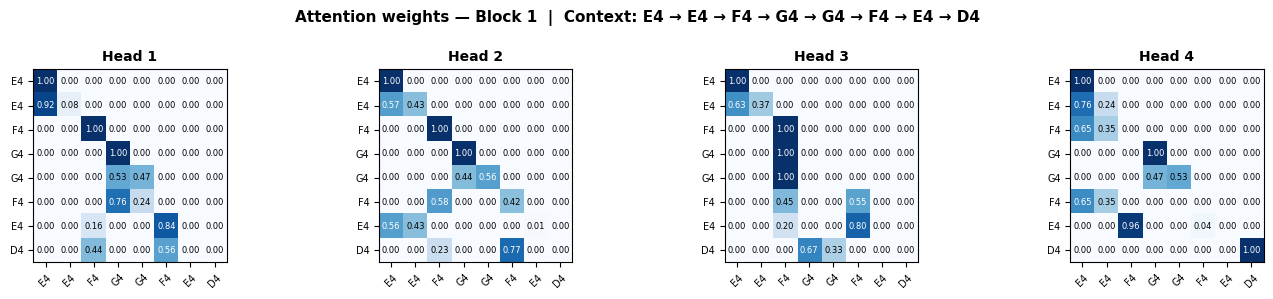


Attention patterns for Fur Elise opening:


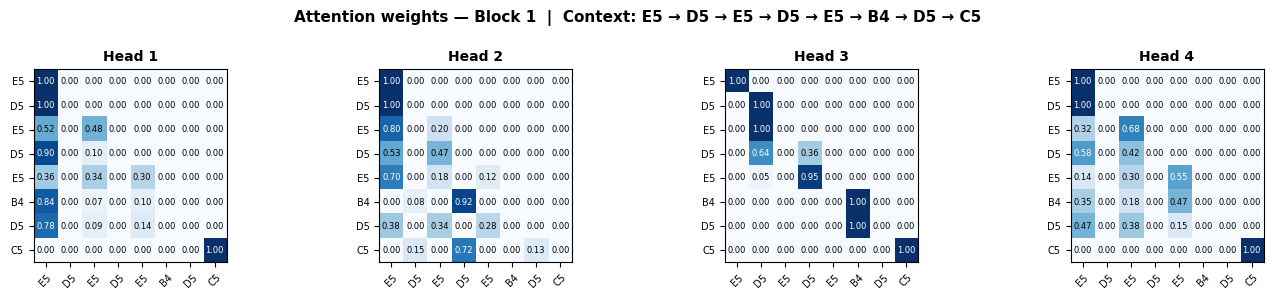

In [ ]:
def plot_attention_heads(context_notes, temperature=1.0):
    """Visualise all 4 attention heads for a given context."""

    ids   = tokenize(context_notes).unsqueeze(0)   # (1, T)
    T     = len(context_notes)

    # Hook to capture attention weights from the first block
    captured = {}
    def hook(module, inp, out):
        B, H_cnt, T_, _ = module._last_weights.shape
        captured['weights'] = module._last_weights.detach()

    # Monkey-patch MHA to expose weights
    original_forward = MultiHeadAttention.forward

    def patched_forward(self, x):
        B, T, D = x.shape
        Q = self.W_q(x); K = self.W_k(x); V = self.W_v(x)
        Q = Q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = K.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        V = V.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)
        mask   = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float('-inf'))
        weights = F.softmax(scores, dim=-1)
        self._last_weights = weights
        context = torch.matmul(self.dropout(weights), V)
        context = context.transpose(1, 2).contiguous().view(B, T, self.d_model)
        return self.W_o(context)

    MultiHeadAttention.forward = patched_forward
    model.eval()
    with torch.no_grad():
        _ = model(ids)
    attn_weights = model.blocks[0].attn._last_weights[0].numpy()   # (H, T, T)
    MultiHeadAttention.forward = original_forward

    fig, axes = plt.subplots(1, N_HEADS, figsize=(14, 3))
    labels = [f"pos {i}\n{n}" for i, n in enumerate(context_notes)]
    for h, ax in enumerate(axes):
        im = ax.imshow(attn_weights[h], cmap='Blues', vmin=0, vmax=1)
        ax.set_title(f"Head {h+1}", fontsize=10, fontweight='bold')
        ax.set_xticks(range(T)); ax.set_xticklabels(context_notes, fontsize=7, rotation=45)
        ax.set_yticks(range(T)); ax.set_yticklabels(context_notes, fontsize=7)
        for i in range(T):
            for j in range(T):
                v = attn_weights[h, i, j]
                ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=6,
                        color='white' if v > 0.55 else 'black')
    fig.suptitle(f"Attention weights — Block 1  |  Context: {' → '.join(context_notes)}",
                 fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()

print("Attention patterns for Ode to Joy opening:")
plot_attention_heads(["E4", "E4", "F4", "G4", "G4", "F4", "E4", "D4"])

print("\nAttention patterns for Fur Elise opening:")
plot_attention_heads(["E5", "D5", "E5", "D5", "E5", "B4", "D5", "C5"])


<div style="font-family: monospace; font-size: 22px; line-height: 2; background-color:#1e1e1e; color:#f0f0f0; padding: 30px; border-radius: 12px; border: 1px solid #444;">
🎹 <b>Architecture</b>
<br><br>
Token IDs&nbsp;&nbsp;→&nbsp;&nbsp;Embedding&nbsp;&nbsp;→&nbsp;&nbsp;PositionalEncoding<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;→&nbsp;&nbsp;TransformerBlock × 2<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;├─ MultiHeadAttention (4 heads, causal mask)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;└─ FeedForward (GELU)<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;↑ both wrapped in: residual + LayerNorm<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;→&nbsp;&nbsp;Linear output head<br>
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;→&nbsp;&nbsp;Logits
</div>